# Phase 4 - Feature Engineering

**Goal**: build a feature vector for every detected bubble that captures its temopral context, spatial properties, and instrument group.

Features captured: 
- iei_prev, iei_prev2 - intervai to the previous bubbles
- density_1s, density_3s, density_1-0s, density_60s - past activity at multiple time scales
- recent_cs_5s - coefficient of variation of recent intervals 
- burst_score - recent activity vs. longer-term average
- n_same_group_3s - same group repetition count
- one-hot encoded group
- area, cx, ay, angle - visual prperties.

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

DATA_CLEAN_DIR = '../data_clean'
df = pd.read_csv(os.path.join(DATA_CLEAN_DIR, 'all_events_clean.csv'))
df = df[~df['in_anomaly']].reset_index(drop=True)
df = df.sort_values('t_rel').reset_index(drop=True)
print(f'Loaded {len(df):,} clean events')

Loaded 4,312 clean events


In [2]:
def build_features(df):
    df = df.sort_values('t_rel').reset_index(drop=True).copy()
    t = df['t_rel'].values

    # --- IEI features ---
    df['iei_prev']  = np.concatenate([[np.nan], np.diff(t)])
    df['iei_prev2'] = np.concatenate([[np.nan, np.nan], np.diff(t, n=2)])

    # --- Density windows (events in last w seconds) ---
    for w in [1, 3, 10, 60]:
        col = f'density_{w}s'
        counts = []
        for ti in t:
            counts.append(((t >= ti - w) & (t < ti)).sum())
        df[col] = counts

    # --- Recent CV of IEI in last 5s ---
    cv5 = []
    for ti in t:
        mask = (t >= ti - 5) & (t < ti)
        ieis = np.diff(t[mask])
        if len(ieis) >= 2 and ieis.mean() > 0:
            cv5.append(ieis.std() / ieis.mean())
        else:
            cv5.append(0.0)
    df['recent_cv_5s'] = cv5

    # --- Burst score = (recent rate) / (longer rate) ---
    df['burst_score'] = (
        (df['density_1s'] / 1.0) /
        (df['density_10s'] / 10.0 + 1e-6)
    ).clip(upper=5.0) / 5.0

    # --- Same-group repetition in last 3s ---
    n_same = []
    for i, row in df.iterrows():
        ti = row['t_rel']
        prev = df[(df['t_rel'] >= ti - 3) & (df['t_rel'] < ti)]
        n_same.append((prev['group'] == row['group']).sum())
    df['n_same_group_3s'] = n_same

    # --- One-hot encode group ---
    onehot = pd.get_dummies(df['group'], prefix='grp')
    df = pd.concat([df, onehot], axis=1)
    return df

In [3]:
print('Building features ... (this takes a minute)')
df_feat = build_features(df)
print(f'Done. {len(df_feat):,} rows, {len(df_feat.columns)} columns.')
df_feat.head()

Building features ... (this takes a minute)
Done. 4,312 rows, 35 columns.


,frame_idx,iso_time,timestamp,t_rel,event_id,selected_event_id,cx,cy,x,y,...,density_10s,density_60s,recent_cv_5s,burst_score,n_same_group_3s,grp_biwa,grp_kakko,grp_koto,grp_shoko,grp_taiko
0,523,2026-05-04T13:04:47.836432,1.777914e+09,36.320053,5336,1.0,338,153,336,151,...,0,0,0.000000,0.000000,0,True,False,False,False,False
1,1074,2026-05-04T13:05:25.387271,1.777914e+09,73.870893,5337,2.0,314,122,310,120,...,0,1,0.000000,0.000000,0,True,False,False,False,False
2,1082,2026-05-04T13:05:25.931485,1.777914e+09,74.415107,5345,NaN,314,123,310,121,...,1,2,0.000000,1.000000,1,True,False,False,False,False
3,1090,2026-05-04T13:05:26.475841,1.777914e+09,74.959463,5353,NaN,314,122,310,120,...,2,3,0.000000,0.999995,2,True,False,False,False,False
4,1098,2026-05-04T13:05:27.019536,1.777914e+09,75.503158,5361,NaN,312,122,310,120,...,3,4,0.000131,0.666664,3,True,False,False,False,False


## 4.2 Inspect feature distributions 

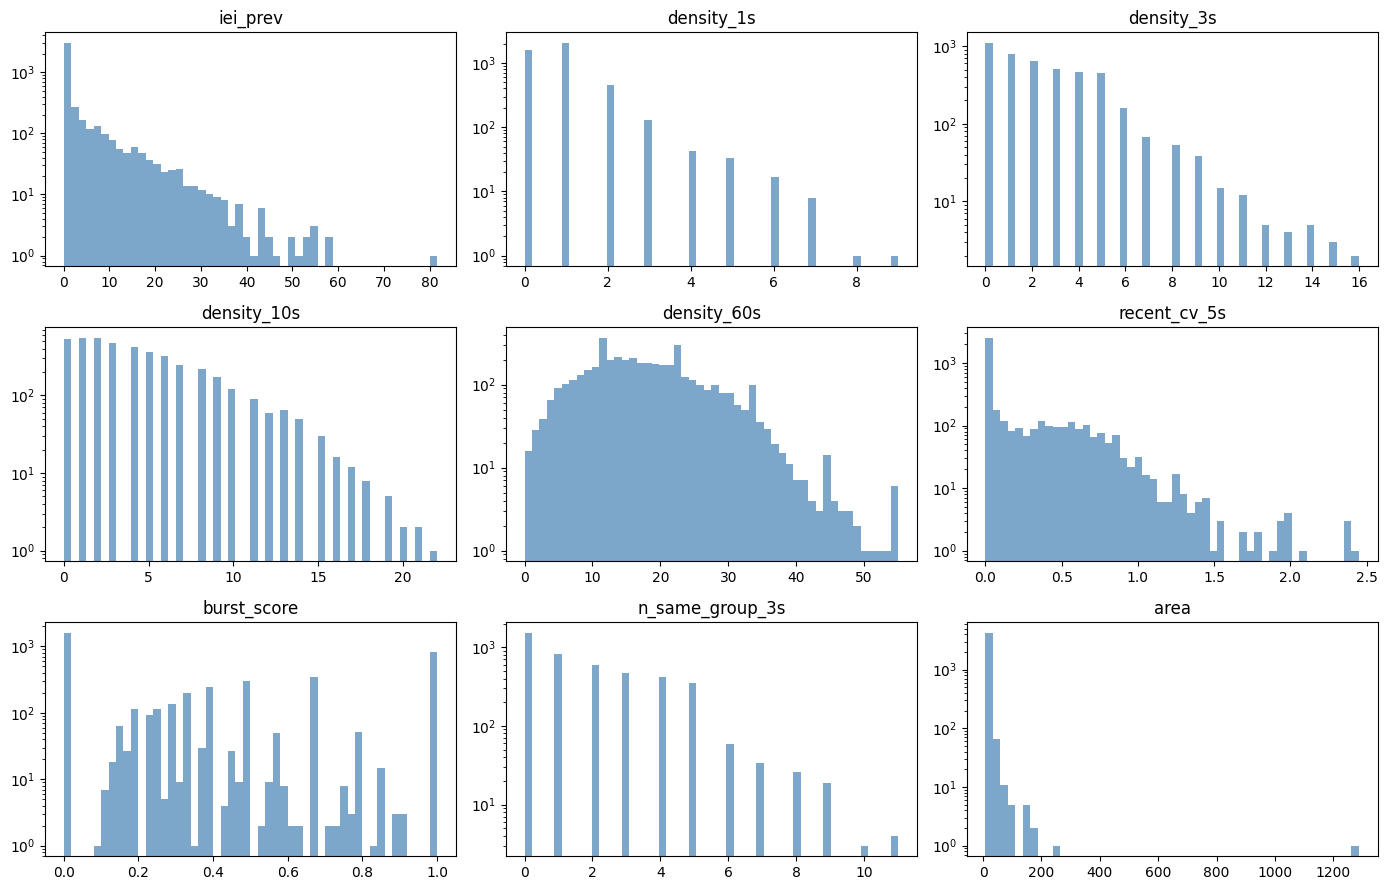

In [4]:
feat_cols = ['iei_prev', 'density_1s', 'density_3s', 'density_10s',
             'density_60s', 'recent_cv_5s', 'burst_score',
             'n_same_group_3s', 'area']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.flat, feat_cols):
    vals = df_feat[col].dropna()
    ax.hist(vals, bins=50, color='steelblue', alpha=0.7)
    ax.set_title(col)
    ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../outputs/plots/15_features.png', dpi=120)
plt.show()

Burst score = [# of bubbles of previous 1s] ] [average # of bubbles / 1s, using the data of # of bubbles detected in previous 10 seconds]
-> normalized to 0-1

0 means that the bubble was detected after at least 1 seconds of silence although there were some bubbles in the previous 10 seconds. 
1 means that the bubble is on a burst 

I should include burst score as one of the elements in the selector in later phase.

## 4.3 Standardize

In [5]:
scaler = StandardScaler()
df_feat[feat_cols] = scaler.fit_transform(df_feat[feat_cols].fillna(0))

print('After standardization:')
print(df_feat[feat_cols].describe().round(3))

After standardization:
       iei_prev  density_1s  density_3s  density_10s  density_60s  \
count  4312.000    4312.000    4312.000     4312.000     4312.000   
mean      0.000       0.000       0.000       -0.000       -0.000   
std       1.000       1.000       1.000        1.000        1.000   
min      -0.517      -0.897      -1.038       -1.177       -2.057   
25%      -0.441      -0.897      -1.038       -0.913       -0.678   
50%      -0.430       0.112      -0.179       -0.122       -0.103   
75%      -0.108       0.112       0.679        0.670        0.586   
max      10.880       8.184       5.831        4.627        4.263   

       recent_cv_5s  burst_score  n_same_group_3s      area  
count      4312.000     4312.000         4312.000  4312.000  
mean         -0.000       -0.000           -0.000     0.000  
std           1.000        1.000            1.000     1.000  
min          -0.633       -1.006           -0.943    -0.238  
25%          -0.633       -1.006           -0

## 4.4 Save

In [6]:
out = os.path.join(DATA_CLEAN_DIR, 'all_events_features.csv')
df_feat.to_csv(out, index=False)
print(f'Saved: {out}')
print(f'  rows    : {len(df_feat):,}')
print(f'  columns : {len(df_feat.columns)}')

Saved: ../data_clean/all_events_features.csv
  rows    : 4,312
  columns : 35
